In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os, numpy as np
import math
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# Load Dataset

In [3]:
DATA_DIR = "fused_dataset"
IMG_SIZE = (128,128)
BATCH_SIZE = 16

train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(class_names)


Found 4318 files belonging to 2 classes.
Using 3455 files for training.
Found 4318 files belonging to 2 classes.
Using 863 files for validation.
['Healthy', 'Tumor']


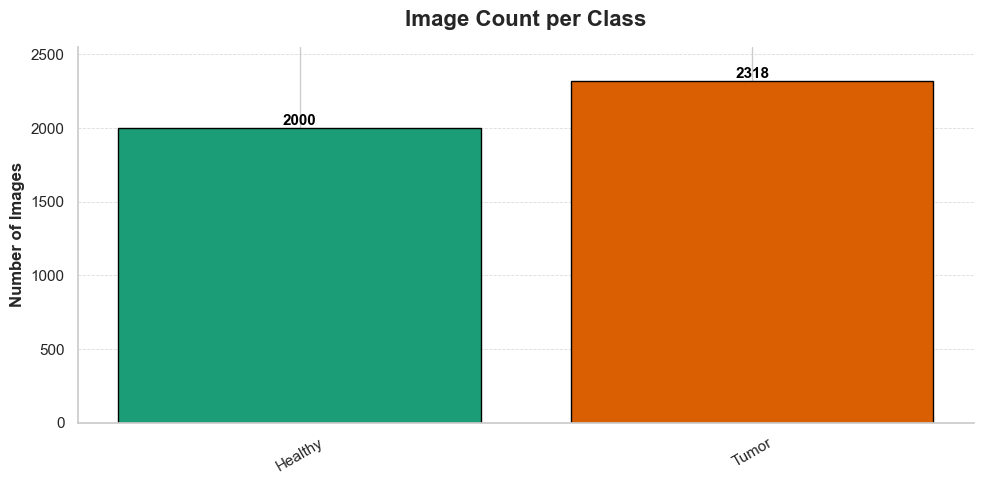

In [4]:
sns.set(style="whitegrid")

classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])

counts = []
for label in classes:
    folder_path = os.path.join(DATA_DIR, label)
    count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
    counts.append(count)

plt.figure(figsize=(10, 5))
colors = sns.color_palette("Dark2", len(classes))
bars = plt.bar(classes, counts, color=colors, edgecolor='black')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', va='bottom', fontsize=11, weight='bold', color='black')
plt.title('Image Count per Class', fontsize=16, weight='bold', pad=15)
plt.ylabel('Number of Images', fontsize=12, weight='bold')
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, max(counts) + max(counts)*0.1)
plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

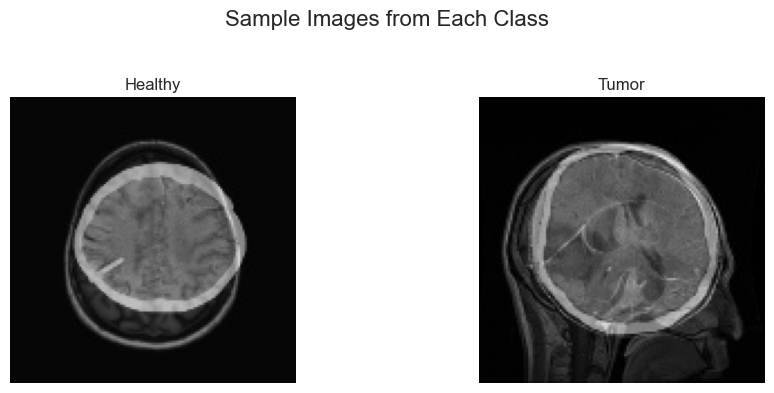

In [5]:
num_classes = len(classes)
cols = 2
rows = math.ceil(num_classes / cols)
plt.figure(figsize=(5 * cols, 4 * rows))
for idx, class_name in enumerate(classes):
    class_path = os.path.join(DATA_DIR, class_name)
    image_files = [f for f in os.listdir(class_path)
                   if os.path.isfile(os.path.join(class_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    if image_files:
        img_path = os.path.join(class_path, image_files[0])
        img = mpimg.imread(img_path)
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Convert to NumPy

In [6]:
def ds_to_numpy(ds):
    x,y=[],[]
    for i,j in ds:
        x.append(i.numpy())
        y.append(j.numpy())
    return np.concatenate(x), np.concatenate(y)

x_train, y_train = ds_to_numpy(train_ds)
x_val, y_val = ds_to_numpy(val_ds)

x_train = preprocess_input(x_train)
x_val = preprocess_input(x_val)

y_train = to_categorical(y_train, NUM_CLASSES)
y_val = to_categorical(y_val, NUM_CLASSES)


In [7]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize


def evaluate_model(y_test, y_pred, y_proba, labels, history=None, model_name="Model"):
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    print(f"\nClassification Report - {model_name}")
    print(classification_report(y_test, y_pred, target_names=labels))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', xticks_rotation=90, ax=axes[0], colorbar=False)
    axes[0].set_title(f"Confusion Matrix - {model_name}")

    if len(np.unique(y_test)) > 2:
        y_test_bin = label_binarize(y_test, classes=range(len(labels)))
        for i in range(len(labels)):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc_val = auc(fpr, tpr)
            axes[1].plot(fpr, tpr, lw=2, label=f"{labels[i]} (AUC={roc_auc_val:.2f})")
        axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
        axes[1].set_title(f"ROC Curve - {model_name}")
        axes[1].legend(loc="lower right", fontsize=8)
    else:
        fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
        roc_auc_val = auc(fpr, tpr)

        axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.2f}")
        axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
        axes[1].set_title(f"ROC Curve - {model_name}")
        axes[1].legend(loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.show()

    if history is not None:
        hist = history.history if hasattr(history, "history") else history

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        axes[0].plot(hist["accuracy"], label="Train Accuracy")
        axes[0].plot(hist["val_accuracy"], label="Val Accuracy")
        axes[0].set_title(f"Training Accuracy - {model_name}")
        axes[0].set_xlabel("Epochs")
        axes[0].set_ylabel("Accuracy")
        axes[0].legend()

        axes[1].plot(hist["loss"], label="Train Loss")
        axes[1].plot(hist["val_loss"], label="Val Loss")
        axes[1].set_title(f"Training Loss - {model_name}")
        axes[1].set_xlabel("Epochs")
        axes[1].set_ylabel("Loss")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    return acc, prec, rec, f1

In [9]:
import os 

os.makedirs("Models", exist_ok=True)

In [10]:
labels = class_names
labels

['Healthy', 'Tumor']

# CNN

In [11]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])


cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 16, 16, 128)      0

In [12]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3)
]

history_cnn = cnn_model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)


Epoch 1/40
216/216 [==============================] - 3s 9ms/step - loss: 1.6251 - accuracy: 0.7777 - val_loss: 0.2816 - val_accuracy: 0.8818 - lr: 1.0000e-04
Epoch 2/40
216/216 [==============================] - 1s 6ms/step - loss: 0.2688 - accuracy: 0.8854 - val_loss: 0.2211 - val_accuracy: 0.9200 - lr: 1.0000e-04
Epoch 3/40
216/216 [==============================] - 2s 7ms/step - loss: 0.1825 - accuracy: 0.9271 - val_loss: 0.1348 - val_accuracy: 0.9432 - lr: 1.0000e-04
Epoch 4/40
216/216 [==============================] - 1s 6ms/step - loss: 0.1200 - accuracy: 0.9560 - val_loss: 0.1259 - val_accuracy: 0.9537 - lr: 1.0000e-04
Epoch 5/40
216/216 [==============================] - 1s 7ms/step - loss: 0.0870 - accuracy: 0.9676 - val_loss: 0.1604 - val_accuracy: 0.9328 - lr: 1.0000e-04
Epoch 6/40
216/216 [==============================] - 2s 8ms/step - loss: 0.0654 - accuracy: 0.9774 - val_loss: 0.0888 - val_accuracy: 0.9652 - lr: 1.0000e-04
Epoch 7/40
216/216 [==========================

In [13]:
cnn_model.save("Models/cnn_fused.h5")

216/216 [==============================] - 1s 2ms/step

Classification Report - CNN_Fused
              precision    recall  f1-score   support

     Healthy       0.98      0.99      0.99       386
       Tumor       0.99      0.99      0.99       477

    accuracy                           0.99       863
   macro avg       0.99      0.99      0.99       863
weighted avg       0.99      0.99      0.99       863



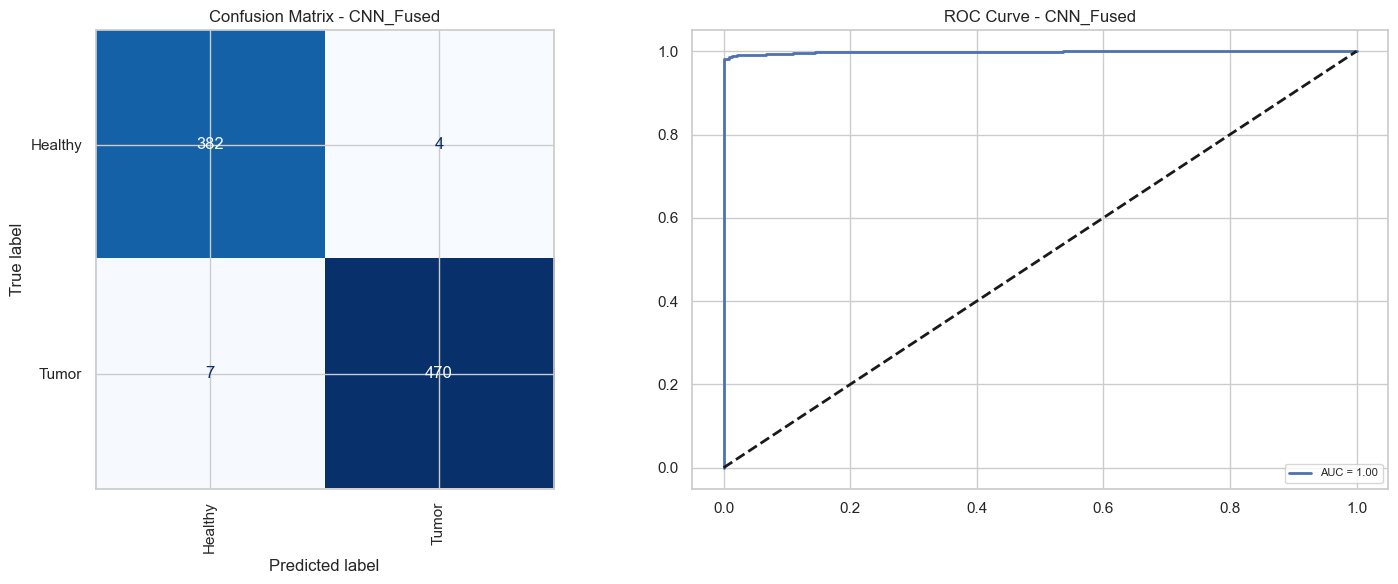

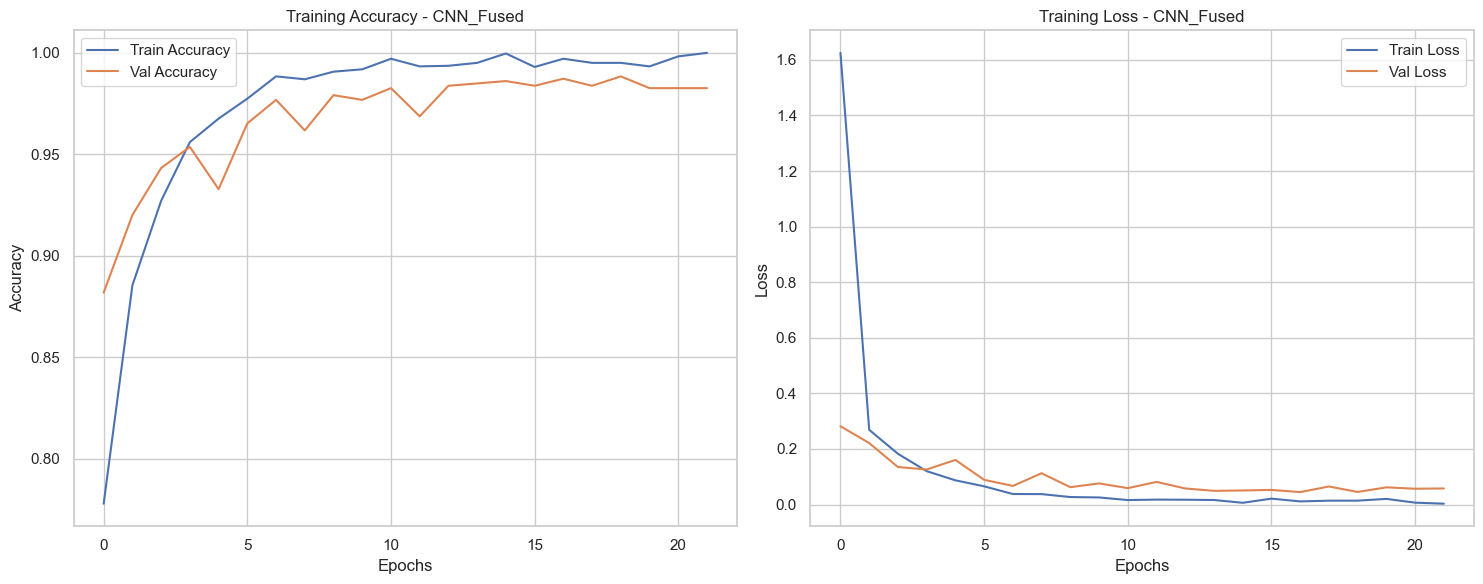

In [14]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_cnn = cnn_model.predict(x_val, batch_size=4)
y_pred_cnn = np.argmax(y_proba_cnn, axis=1)

acc_cnn, prec_cnn, rec_cnn, f1_cnn = evaluate_model(
    y_val_int, y_pred_cnn, y_proba_cnn, labels, history=history_cnn, model_name="CNN_Fused"
)

In [15]:
storeResults("cnn", acc_cnn, prec_cnn, rec_cnn, f1_cnn)

# VGG16

In [16]:
base = VGG16(weights="imagenet", include_top=False,
             input_shape=(128,128,3))
base.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

vgg16_model = tf.keras.Model(base.input, out)

vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.00008),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

vgg16_model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0     

In [17]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3)
]

history_vgg16 = vgg16_model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(x_val,y_val),
    callbacks=callbacks
)


Epoch 1/40
216/216 [==============================] - 3s 11ms/step - loss: 2.0964 - accuracy: 0.6961 - val_loss: 0.3862 - val_accuracy: 0.8911 - lr: 8.0000e-05
Epoch 2/40
216/216 [==============================] - 2s 8ms/step - loss: 0.8557 - accuracy: 0.8350 - val_loss: 0.2548 - val_accuracy: 0.9282 - lr: 8.0000e-05
Epoch 3/40
216/216 [==============================] - 2s 8ms/step - loss: 0.6060 - accuracy: 0.8648 - val_loss: 0.2114 - val_accuracy: 0.9340 - lr: 8.0000e-05
Epoch 4/40
216/216 [==============================] - 2s 8ms/step - loss: 0.4776 - accuracy: 0.8761 - val_loss: 0.1839 - val_accuracy: 0.9374 - lr: 8.0000e-05
Epoch 5/40
216/216 [==============================] - 2s 8ms/step - loss: 0.4057 - accuracy: 0.8967 - val_loss: 0.1837 - val_accuracy: 0.9386 - lr: 8.0000e-05
Epoch 6/40
216/216 [==============================] - 2s 8ms/step - loss: 0.3034 - accuracy: 0.9091 - val_loss: 0.1524 - val_accuracy: 0.9455 - lr: 8.0000e-05
Epoch 7/40
216/216 [=========================

In [18]:
vgg16_model.save("Models/vgg16_fused.h5")

216/216 [==============================] - 1s 4ms/step

Classification Report - vgg16_Fused
              precision    recall  f1-score   support

     Healthy       0.96      0.97      0.97       386
       Tumor       0.97      0.97      0.97       477

    accuracy                           0.97       863
   macro avg       0.97      0.97      0.97       863
weighted avg       0.97      0.97      0.97       863



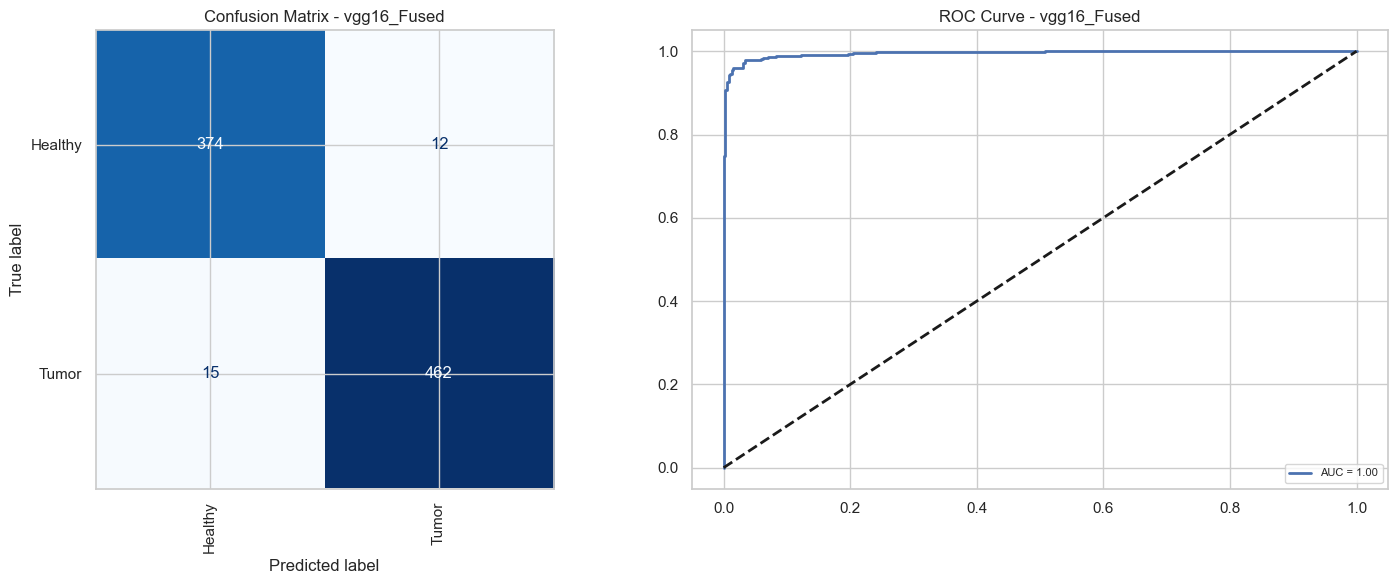

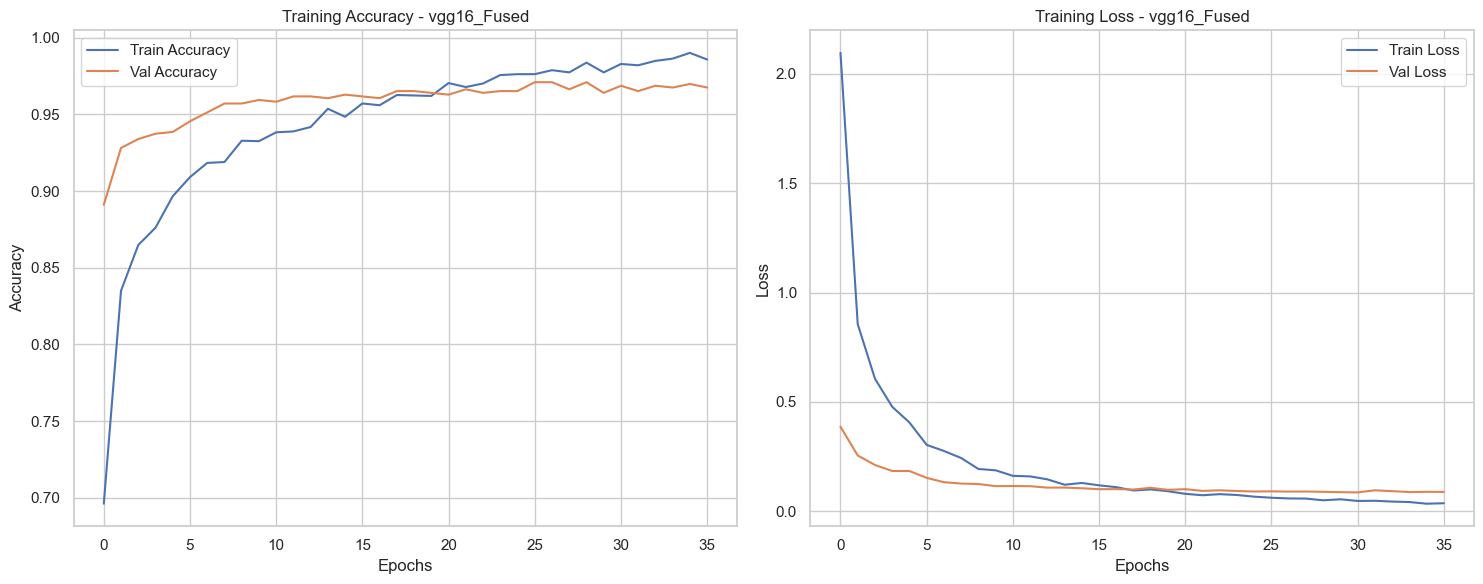

In [19]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_vgg16 = vgg16_model.predict(x_val, batch_size=4)
y_pred_vgg16 = np.argmax(y_proba_vgg16, axis=1)

acc_vgg16, prec_vgg16, rec_vgg16, f1_vgg16 = evaluate_model(
    y_val_int, y_pred_vgg16, y_proba_vgg16, labels, history=history_vgg16, model_name="vgg16_Fused"
) 

In [20]:
storeResults("vgg16", acc_vgg16, prec_vgg16, rec_vgg16, f1_vgg16)

# ResNet50

In [21]:
from tensorflow.keras.applications import ResNet50

base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_resnet.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_resnet.output)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

resnet50_model = tf.keras.Model(base_resnet.input, out)

resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00008),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

resnet50_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_3[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']       

 conv2_block3_2_conv (Conv2D)   (None, 32, 32, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 32, 32, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 32, 32, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_3_conv (Conv2D)   (None, 32, 32, 256)  16640       ['conv2_block3_2_relu[0][0]']    
                                                                                                  
 conv2_blo

 conv3_block3_2_conv (Conv2D)   (None, 16, 16, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_3_conv (Conv2D)   (None, 16, 16, 512)  66048       ['conv3_block3_2_relu[0][0]']    
                                                                                                  
 conv3_blo

 conv4_block2_2_conv (Conv2D)   (None, 8, 8, 256)    590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 8, 8, 256)   1024        ['conv4_block2_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block2_2_relu[0][0]']    
                                                                                                  
 conv4_blo

 conv4_block5_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block5_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block5_2_relu[0][0]']    
                                                                                                  
 conv4_block5_3_bn (BatchNormal  (None, 8, 8, 1024)  4096        ['conv4_block5_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_add (Add)         (None, 8, 8, 1024)   0           ['conv4_block4_out[0][0]',       
                                                                  'conv4_block5_3_bn[0][0]']      
          

 conv5_block2_2_relu (Activatio  (None, 4, 4, 512)   0           ['conv5_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_block2_3_conv (Conv2D)   (None, 4, 4, 2048)   1050624     ['conv5_block2_2_relu[0][0]']    
                                                                                                  
 conv5_block2_3_bn (BatchNormal  (None, 4, 4, 2048)  8192        ['conv5_block2_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_add (Add)         (None, 4, 4, 2048)   0           ['conv5_block1_out[0][0]',       
                                                                  'conv5_block2_3_bn[0][0]']      
          

In [22]:
history_resnet50 = resnet50_model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)

Epoch 1/40
216/216 [==============================] - 7s 21ms/step - loss: 0.4213 - accuracy: 0.8272 - val_loss: 0.2066 - val_accuracy: 0.9235 - lr: 8.0000e-05
Epoch 2/40
216/216 [==============================] - 3s 15ms/step - loss: 0.2342 - accuracy: 0.9062 - val_loss: 0.1689 - val_accuracy: 0.9316 - lr: 8.0000e-05
Epoch 3/40
216/216 [==============================] - 3s 15ms/step - loss: 0.1812 - accuracy: 0.9250 - val_loss: 0.1479 - val_accuracy: 0.9421 - lr: 8.0000e-05
Epoch 4/40
216/216 [==============================] - 3s 15ms/step - loss: 0.1601 - accuracy: 0.9412 - val_loss: 0.1343 - val_accuracy: 0.9479 - lr: 8.0000e-05
Epoch 5/40
216/216 [==============================] - 3s 15ms/step - loss: 0.1322 - accuracy: 0.9476 - val_loss: 0.1217 - val_accuracy: 0.9537 - lr: 8.0000e-05
Epoch 6/40
216/216 [==============================] - 3s 14ms/step - loss: 0.1285 - accuracy: 0.9520 - val_loss: 0.1239 - val_accuracy: 0.9537 - lr: 8.0000e-05
Epoch 7/40
216/216 [====================

In [23]:
resnet50_model.save("Models/resnet50_fused.h5")

216/216 [==============================] - 3s 10ms/step

Classification Report - resnet50_Fused
              precision    recall  f1-score   support

     Healthy       0.96      0.97      0.96       386
       Tumor       0.97      0.96      0.97       477

    accuracy                           0.97       863
   macro avg       0.97      0.97      0.97       863
weighted avg       0.97      0.97      0.97       863



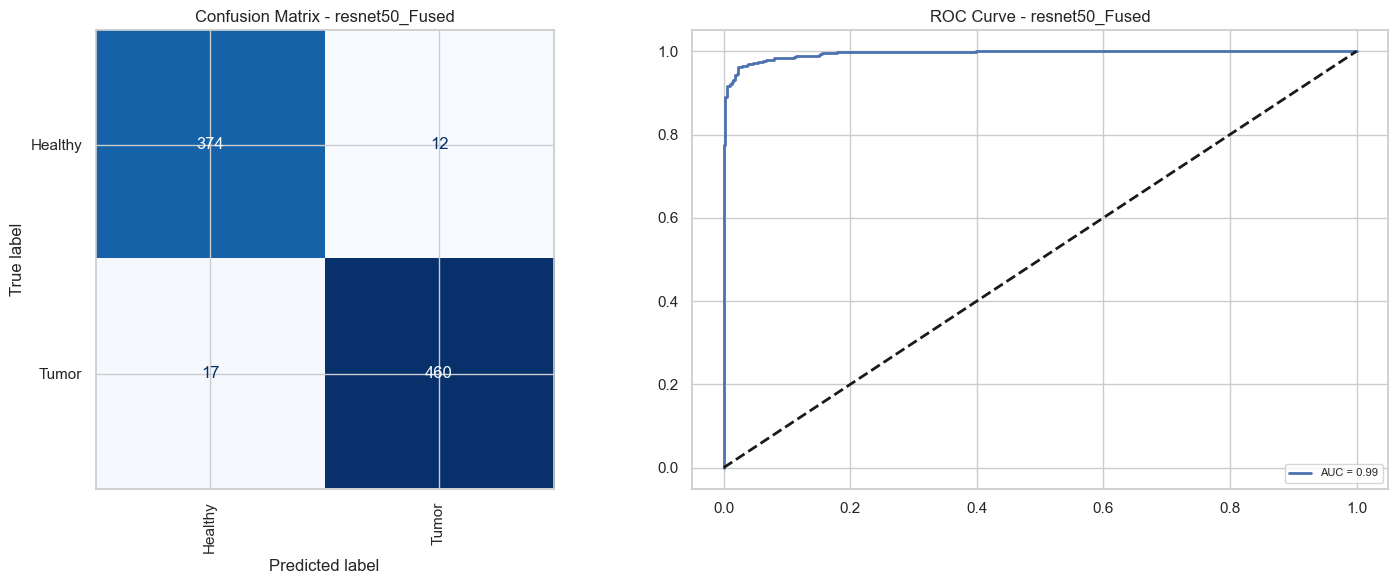

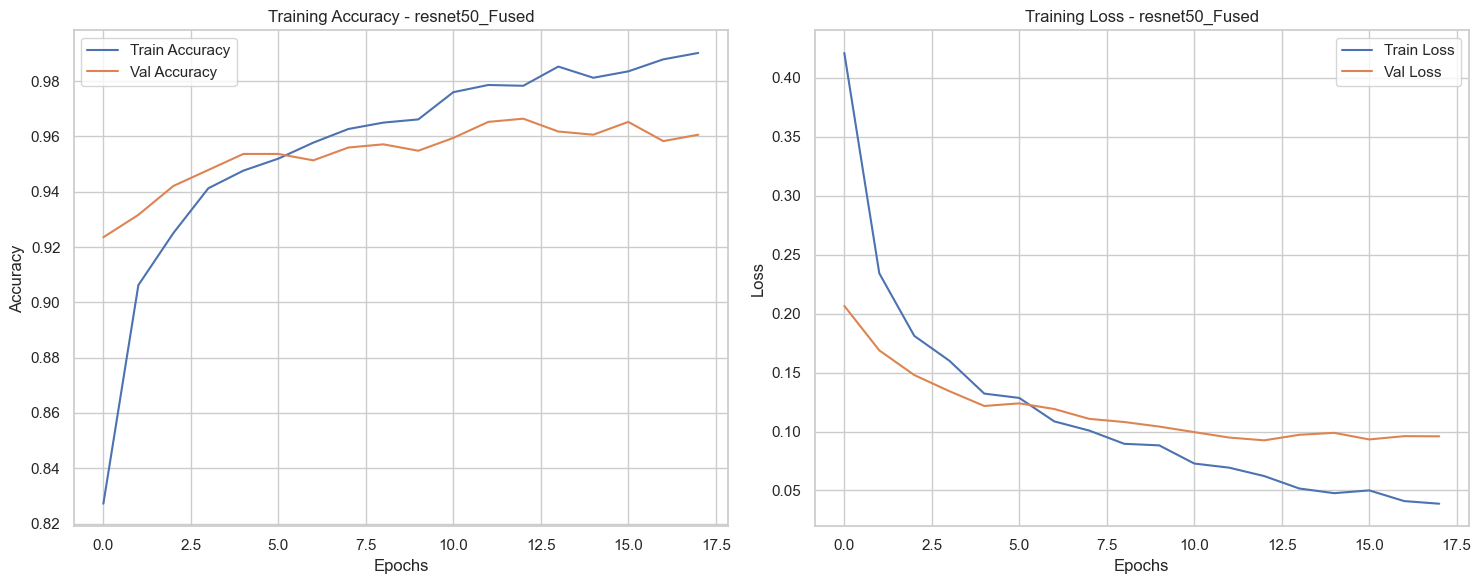

In [24]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_resnet50 = resnet50_model.predict(x_val, batch_size=4)
y_pred_resnet50 = np.argmax(y_proba_resnet50, axis=1)

acc_resnet50, prec_resnet50, rec_resnet50, f1_resnet50 = evaluate_model(
    y_val_int, y_pred_resnet50, y_proba_resnet50, labels, history=history_resnet50, model_name="resnet50_Fused"
)

In [25]:
storeResults("resnet50", acc_resnet50, prec_resnet50, rec_resnet50, f1_resnet50)

# Xception

In [26]:
from tensorflow.keras.applications import Xception

base_xception = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_xception.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_xception.output)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

xception_model = tf.keras.Model(base_xception.input, out)

xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00008),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

xception_model.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 63, 63, 32)   864         ['input_4[0][0]']                
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 63, 63, 32)  128         ['block1_conv1[0][0]']           
 ation)                                                                                           
                                                                                            

 n)                                                                                               
                                                                                                  
 block4_sepconv2 (SeparableConv  (None, 16, 16, 728)  536536     ['block4_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block4_sepconv2_bn (BatchNorma  (None, 16, 16, 728)  2912       ['block4_sepconv2[0][0]']        
 lization)                                                                                        
                                                                                                  
 conv2d_5 (Conv2D)              (None, 8, 8, 728)    186368      ['add_1[0][0]']                  
                                                                                                  
 block4_po

                                                                                                  
 block7_sepconv1_bn (BatchNorma  (None, 8, 8, 728)   2912        ['block7_sepconv1[0][0]']        
 lization)                                                                                        
                                                                                                  
 block7_sepconv2_act (Activatio  (None, 8, 8, 728)   0           ['block7_sepconv1_bn[0][0]']     
 n)                                                                                               
                                                                                                  
 block7_sepconv2 (SeparableConv  (None, 8, 8, 728)   536536      ['block7_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block7_se

                                                                  'add_6[0][0]']                  
                                                                                                  
 block10_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_7[0][0]']                  
 on)                                                                                              
                                                                                                  
 block10_sepconv1 (SeparableCon  (None, 8, 8, 728)   536536      ['block10_sepconv1_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block10_sepconv1_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block10_sepconv1[0][0]']       
 alization)                                                                                       
          

 block12_sepconv3 (SeparableCon  (None, 8, 8, 728)   536536      ['block12_sepconv3_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block12_sepconv3_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block12_sepconv3[0][0]']       
 alization)                                                                                       
                                                                                                  
 add_10 (Add)                   (None, 8, 8, 728)    0           ['block12_sepconv3_bn[0][0]',    
                                                                  'add_9[0][0]']                  
                                                                                                  
 block13_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_10[0][0]']                 
 on)      

In [27]:
history_xception = xception_model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)

Epoch 1/40
216/216 [==============================] - 6s 18ms/step - loss: 1.7516 - accuracy: 0.7132 - val_loss: 0.4152 - val_accuracy: 0.8436 - lr: 8.0000e-05
Epoch 2/40
216/216 [==============================] - 2s 11ms/step - loss: 0.5577 - accuracy: 0.8006 - val_loss: 0.3394 - val_accuracy: 0.8540 - lr: 8.0000e-05
Epoch 3/40
216/216 [==============================] - 2s 11ms/step - loss: 0.4118 - accuracy: 0.8217 - val_loss: 0.3421 - val_accuracy: 0.8494 - lr: 8.0000e-05
Epoch 4/40
216/216 [==============================] - 2s 11ms/step - loss: 0.3568 - accuracy: 0.8414 - val_loss: 0.3149 - val_accuracy: 0.8575 - lr: 8.0000e-05
Epoch 5/40
216/216 [==============================] - 3s 12ms/step - loss: 0.3429 - accuracy: 0.8550 - val_loss: 0.3234 - val_accuracy: 0.8552 - lr: 8.0000e-05
Epoch 6/40
216/216 [==============================] - 3s 13ms/step - loss: 0.3291 - accuracy: 0.8527 - val_loss: 0.3083 - val_accuracy: 0.8552 - lr: 8.0000e-05
Epoch 7/40
216/216 [====================

In [28]:
xception_model.save("Models/xception_fused.h5")

216/216 [==============================] - 2s 7ms/step

Classification Report - xception_Fused
              precision    recall  f1-score   support

     Healthy       0.86      0.88      0.87       386
       Tumor       0.90      0.89      0.89       477

    accuracy                           0.88       863
   macro avg       0.88      0.88      0.88       863
weighted avg       0.88      0.88      0.88       863



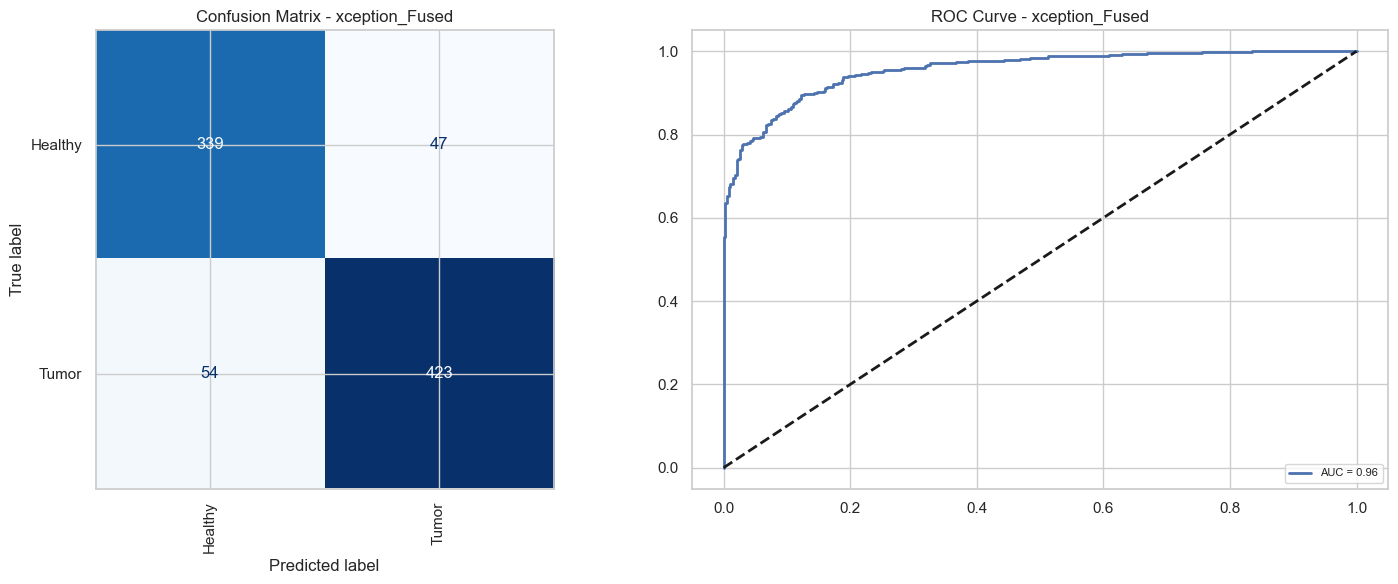

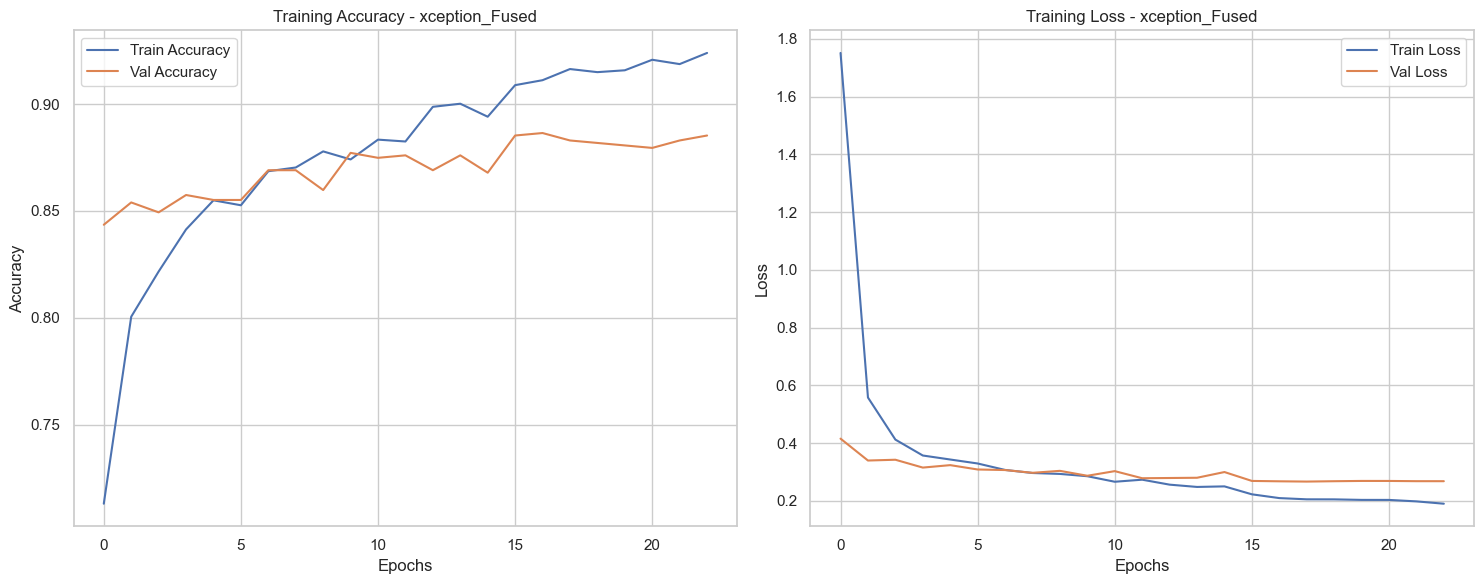

In [29]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_xception = xception_model.predict(x_val, batch_size=4)
y_pred_xception = np.argmax(y_proba_xception, axis=1)

acc_xception, prec_xception, rec_xception, f1_xception = evaluate_model(
    y_val_int, y_pred_xception, y_proba_xception, labels, history=history_xception, model_name="xception_Fused"
)

In [30]:
storeResults("xception", acc_xception, prec_xception, rec_xception, f1_xception)

# Comparison Table

In [31]:
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'Recall'   : recall, 
                       'F1_score' : f1score                   
                      })

In [32]:
result

,ML Model,Accuracy,Precision,Recall,F1_score
0,cnn,0.987,0.987,0.987,0.987
1,vgg16,0.969,0.968,0.969,0.968
2,resnet50,0.966,0.966,0.967,0.966
3,xception,0.883,0.881,0.883,0.882


# Comparison Graphs

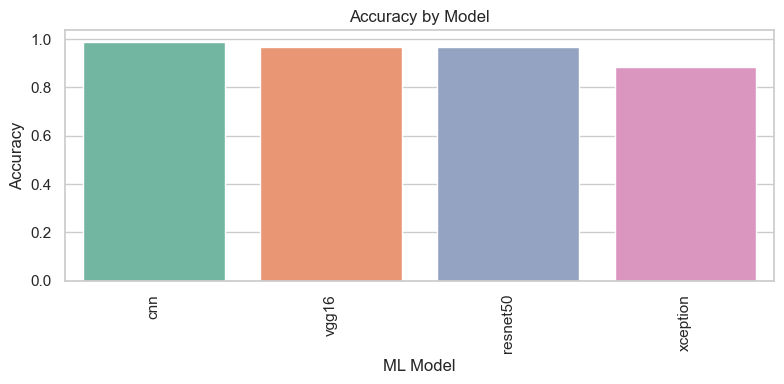

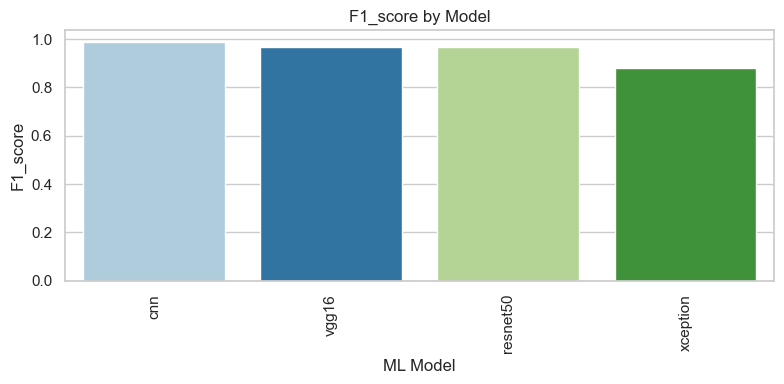

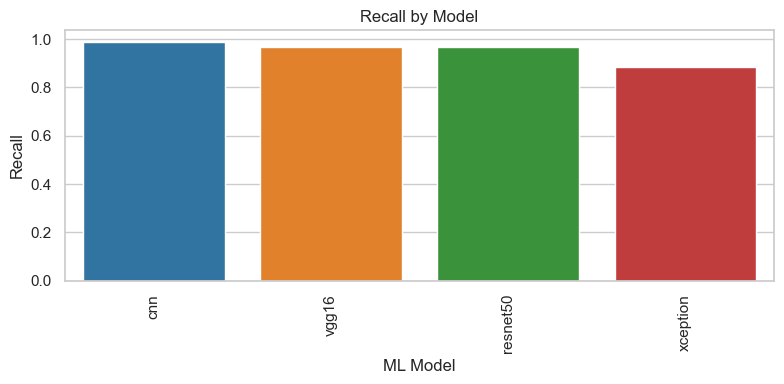

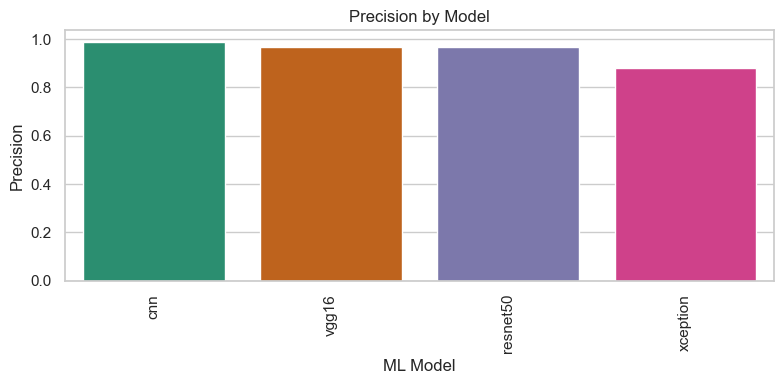

In [34]:
palettes = ['Set2', 'Paired', 'tab10', 'Dark2']

for metric, pal in zip(['Accuracy','F1_score','Recall','Precision'], palettes):
    plt.figure(figsize=(8, 4))
    sns.barplot(data=result, x='ML Model', y=metric, palette=sns.color_palette(pal))
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# Prediction

In [53]:
import numpy as np
from tensorflow.keras.models import load_model
import cv2

model = load_model('Models/cnn_fused.h5',  compile=False)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 16, 16, 128)      0

In [54]:
import cv2
import numpy as np
from tensorflow.keras.applications.vgg16 import preprocess_input

def fuse_ct_mri(ct_path, mri_path):
    ct = cv2.imread(ct_path, 0)
    mri = cv2.imread(mri_path, 0)

    ct = cv2.resize(ct, (128,128))
    mri = cv2.resize(mri, (128,128))

    fused = cv2.addWeighted(ct, 0.5, mri, 0.5, 0)
    fused = cv2.cvtColor(fused, cv2.COLOR_GRAY2RGB)

    fused = fused.astype("float32")
    fused = preprocess_input(fused)  

    return fused


In [55]:
ct_path = "dataset/CT/Healthy/ct_healthy (1).jpg"
mri_path = "dataset/MRI/Healthy/mri_healthy (1).jpg"

fused_img = fuse_ct_mri(ct_path, mri_path)
input_tensor = np.expand_dims(fused_img, axis=0)
pred = model.predict(input_tensor)
predicted_class = np.argmax(pred, axis=1)[0]

class_names = ["Healthy", "Tumor"]
print("Predicted Class:", class_names[predicted_class])
print("Confidence:", np.max(pred))


1/1 [==============================] - 0s 62ms/step
Predicted Class: Healthy
Confidence: 0.9997892


# Grad-CAM

In [65]:
LAST_CONV_LAYER = "conv2d_2"

In [66]:
from tensorflow.keras.models import Model

def make_gradcam(model, img_tensor, class_idx):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(LAST_CONV_LAYER).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    return heatmap


In [67]:
heatmap = make_gradcam(model, input_tensor, predicted_class)

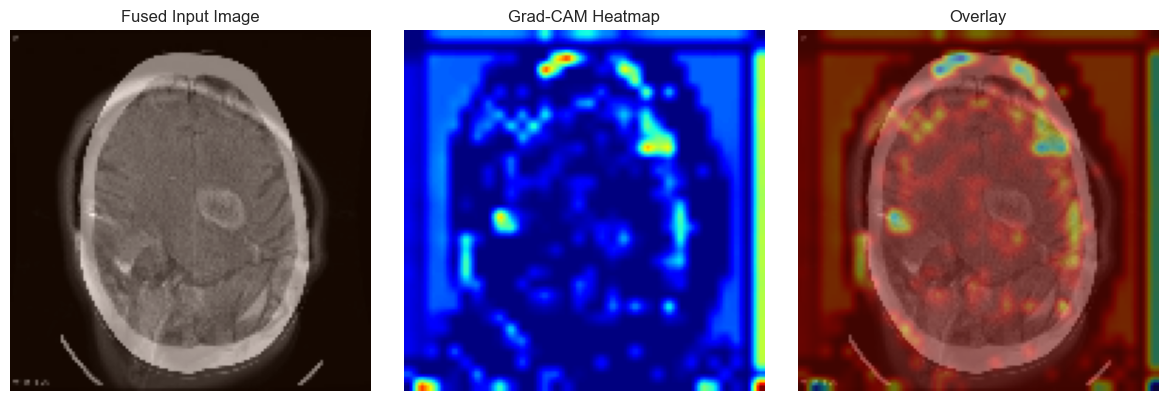

In [68]:
# Convert fused image back for visualization
fused_vis = fused_img.copy()

# Undo preprocess_input effect for display
fused_vis = fused_vis - np.min(fused_vis)
fused_vis = fused_vis / np.max(fused_vis)
fused_vis = np.uint8(255 * fused_vis)

heatmap = cv2.resize(heatmap, (128,128))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

superimposed = cv2.addWeighted(fused_vis, 0.6, heatmap_color, 0.4, 0)


plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Fused Input Image")
plt.imshow(fused_vis)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap, cmap="jet")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(superimposed)
plt.axis("off")

plt.tight_layout()
plt.show()
